In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/Dataset/Dengue-Dataset.csv"

df = pd.read_csv(DATA_PATH)
display(df.head())
print("Kich thuoc du lieu:", df.shape)
print("\nKieu du lieu:")
print(df.dtypes)
print("\nThong ke mo ta:")
display(df.describe())

,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,Male,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive
1,Male,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive
2,Male,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative
3,Female,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative
4,Male,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative


Kich thuoc du lieu: (1523, 19)

Kieu du lieu:
Gender                          object
Age                              int64
Hemoglobin(g/dl)               float64
Neutrophils(%)                   int64
Lymphocytes(%)                   int64
Monocytes(%)                     int64
Eosinophils(%)                   int64
RBC                              int64
HCT(%)                         float64
MCV(fl)                        float64
MCH(pg)                        float64
MCHC(g/dl)                     float64
RDW-CV(%)                      float64
Total Platelet Count(/cumm)      int64
MPV(fl)                        float64
PDW(%)                         float64
PCT(%)                         float64
Total WBC count(/cumm)           int64
Result                          object
dtype: object

Thong ke mo ta:


,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm)
count,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000
mean,40.310571,14.513451,44.484570,43.559422,3.270519,3.083388,4.765594,45.189280,89.815561,29.897225,32.050271,13.635792,173127.170716,9.588806,15.312966,0.289080,5483.024951
std,15.286190,1.627142,4.344736,4.972815,1.209507,1.000791,0.722874,3.566435,5.515619,2.026022,1.551697,1.430746,64832.681751,0.848706,1.405457,5.992864,1137.344040
min,5.000000,10.400000,29.000000,29.000000,2.000000,1.000000,4.000000,36.300000,80.000000,22.900000,27.080000,11.000000,56000.000000,7.500000,8.400000,0.000020,3500.000000
25%,28.000000,13.200000,42.000000,41.000000,2.000000,2.000000,4.000000,42.595000,85.100000,28.400000,30.900000,12.400000,114907.000000,8.900000,14.230000,0.106000,4626.000000
50%,39.000000,14.600000,45.000000,44.000000,3.000000,3.000000,5.000000,45.550000,89.700000,30.000000,32.000000,13.800000,167385.000000,9.660000,15.260000,0.141000,5397.000000
75%,53.000000,15.800000,48.000000,47.000000,4.000000,4.000000,5.000000,47.840000,94.200000,31.400000,33.200000,14.700000,228649.500000,10.283000,16.400000,0.173000,6131.500000
max,78.000000,17.500000,60.000000,56.000000,9.000000,9.000000,7.000000,51.980000,100.000000,34.000000,35.000000,21.330000,299803.000000,11.235000,17.990000,234.000000,14900.000000


In [4]:
pollutant_cols = [
    "Age","Hemoglobin(g/dl)", "Neutrophils(%)", "Lymphocytes(%)",
    "Monocytes(%)","Eosinophils(%)", "RBC", "HCT(%)", "MCV(fl)", "MCH(pg)",
    "MCHC(g/dl)", "RDW-CV(%)", "Total Platelet Count(/cumm)", "MPV(fl)", "PDW(%)", "PCT(%)"
    , "Total WBC count(/cumm)"
    ]
invalid_counts = (df[pollutant_cols] < 0).sum().to_frame("invalid_negative_count")
print("So luong gia tri khong hop le:")
print(invalid_counts)

So luong gia tri khong hop le:
                             invalid_negative_count
Age                                               0
Hemoglobin(g/dl)                                  0
Neutrophils(%)                                    0
Lymphocytes(%)                                    0
Monocytes(%)                                      0
Eosinophils(%)                                    0
RBC                                               0
HCT(%)                                            0
MCV(fl)                                           0
MCH(pg)                                           0
MCHC(g/dl)                                        0
RDW-CV(%)                                         0
Total Platelet Count(/cumm)                       0
MPV(fl)                                           0
PDW(%)                                            0
PCT(%)                                            0
Total WBC count(/cumm)                            0


In [5]:
missing_raw = df.isnull().sum().to_frame("missing_count")
missing_raw["missing_percent"] = missing_raw["missing_count"]/len(df) *100
print("Du lieu thieu:")
display(missing_raw)

daily_imputer = df[pollutant_cols].copy()



Du lieu thieu:


,missing_count,missing_percent
Gender,0,0.0
Age,0,0.0
Hemoglobin(g/dl),0,0.0
Neutrophils(%),0,0.0
Lymphocytes(%),0,0.0
Monocytes(%),0,0.0
Eosinophils(%),0,0.0
RBC,0,0.0
HCT(%),0,0.0
MCV(fl),0,0.0


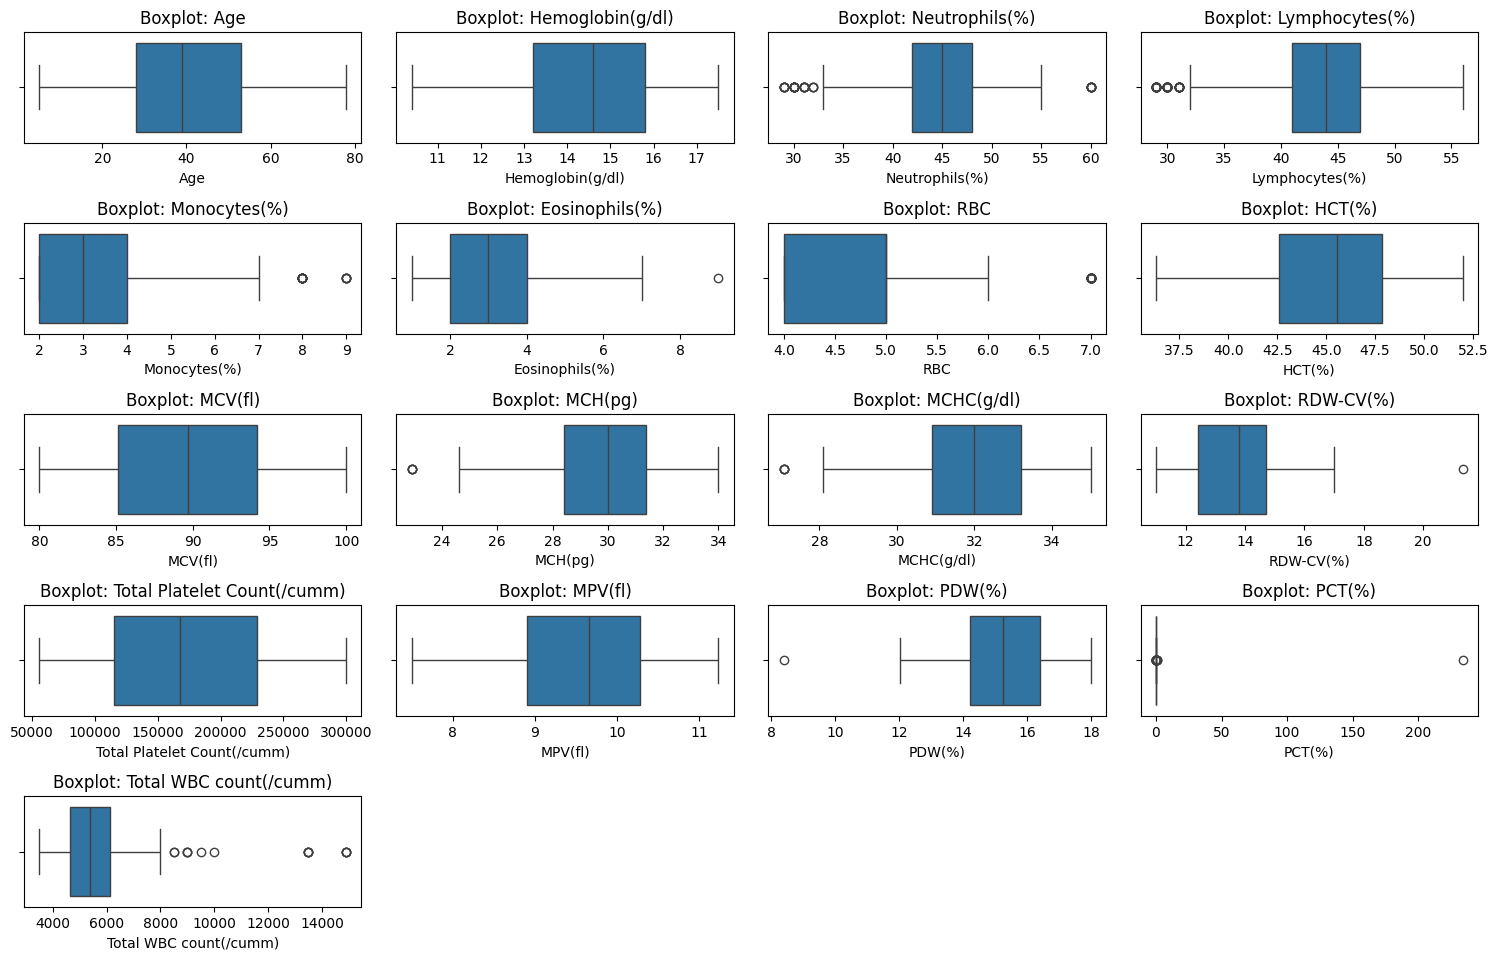

In [6]:
plt.figure(figsize=(15,15))
for i, col in enumerate(pollutant_cols,1):
  plt.subplot(8,4,i)
  sns.boxplot(x=daily_imputer[col])
  plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [7]:
def count_outliers_iqr(df, columns):
  rows = []
  for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 -q1
    lower, upper = q1 - 1.5*iqr, q3+1.5*iqr
    n_outlier = ((df[col]<lower)|(df[col]>upper)).sum()
    rows.append({
        "feature": col,
        "Q1" : q1,
        "Q3" : q3,
        "IQR" : iqr,
        "lower_bound" : lower,
        "upper_bound" : upper,
        "n_outlier" : n_outlier
    })
  return pd.DataFrame(rows)

outlier_report_before = count_outliers_iqr(daily_imputer, pollutant_cols)
display(outlier_report_before)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outlier
0,Age,28.000,53.000,25.000,-9.5000,90.5000,0
1,Hemoglobin(g/dl),13.200,15.800,2.600,9.3000,19.7000,0
2,Neutrophils(%),42.000,48.000,6.000,33.0000,57.0000,36
3,Lymphocytes(%),41.000,47.000,6.000,32.0000,56.0000,69
4,Monocytes(%),2.000,4.000,2.000,-1.0000,7.0000,17
5,Eosinophils(%),2.000,4.000,2.000,-1.0000,7.0000,1
6,RBC,4.000,5.000,1.000,2.5000,6.5000,33
7,HCT(%),42.595,47.840,5.245,34.7275,55.7075,0
8,MCV(fl),85.100,94.200,9.100,71.4500,107.8500,0
9,MCH(pg),28.400,31.400,3.000,23.9000,35.9000,4


In [8]:
daily_imputer_clean = df.copy()

mask = daily_imputer_clean["PCT(%)"] > 1

daily_imputer_clean.loc[mask, "PCT(%)"] = (
    daily_imputer_clean.loc[mask, "Total Platelet Count(/cumm)"] *
    daily_imputer_clean.loc[mask, "MPV(fl)"]
) / 10000000


PCT (Plateletcrit) là tỷ lệ thể tích tiểu cầu trong toàn bộ thể tích máu, thường không vượt quá 1


MPV (Mean Platelet Volume) là thể tích trung bình của một tiểu cầu, tức là cho biết một tiểu cầu có kích thước trung bình là bao nhiêu.

Total Platelet Count (/cumm) là tổng số lượng tiểu cầu trong một đơn vị thể tích máu.

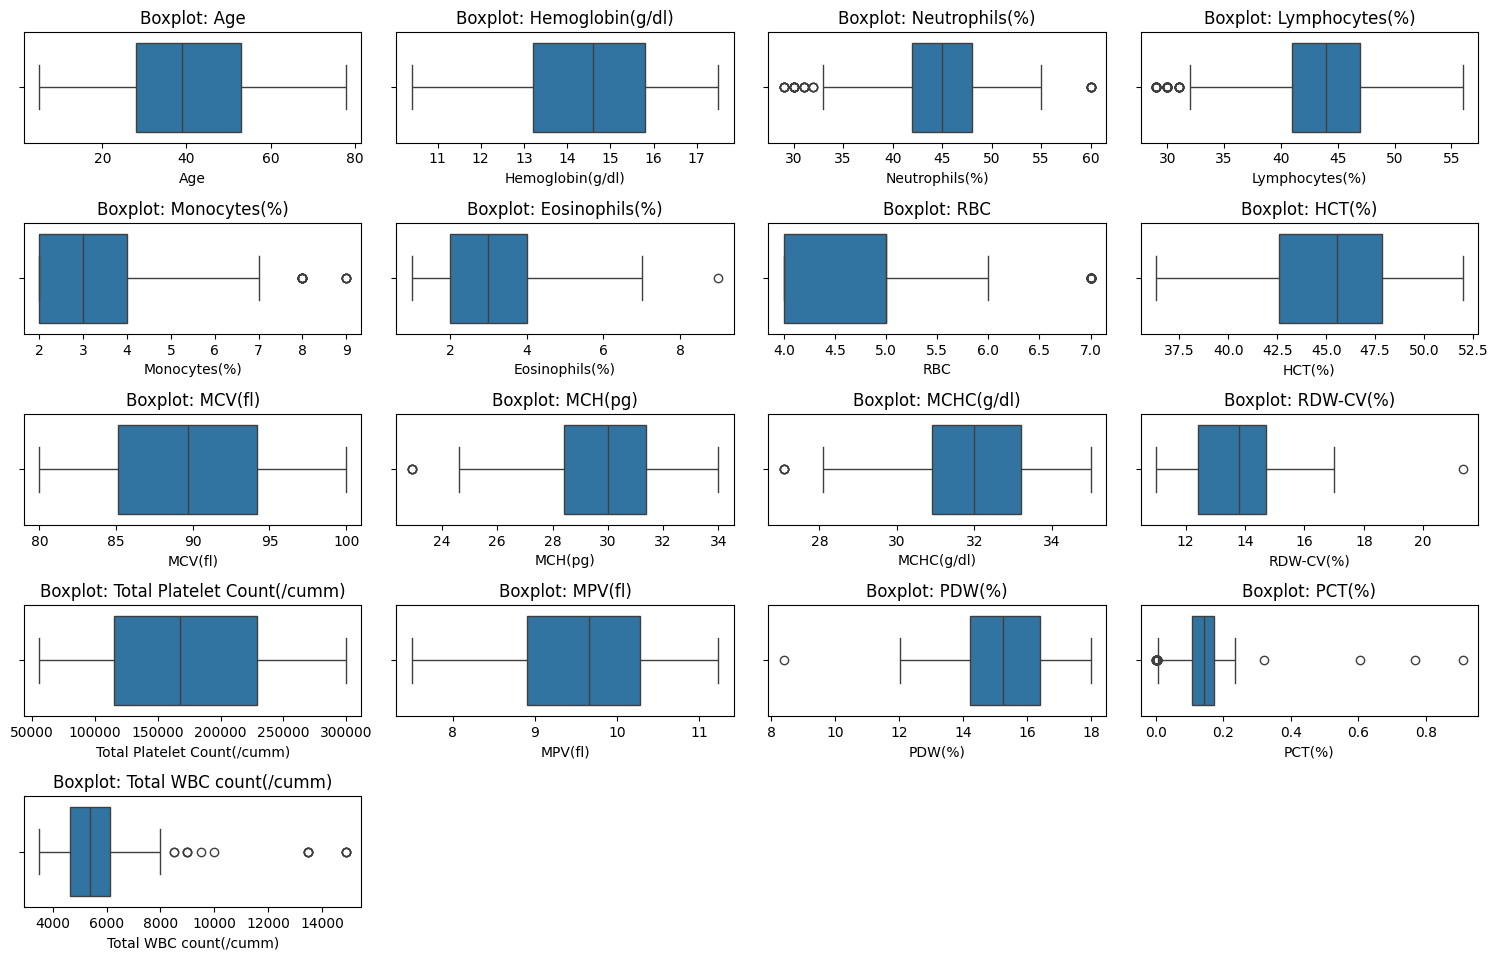

In [9]:
plt.figure(figsize=(15,15))
for i, col in enumerate(pollutant_cols,1):
  plt.subplot(8,4,i)
  sns.boxplot(x=daily_imputer_clean[col])
  plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [10]:
df["Result"] = df["Result"].map({
    "positive": 1,
    "negative": 0
})
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})
print(df["Gender"].value_counts(dropna=False))
print(df["Gender"].isna().sum())
print(df["Result"].value_counts(dropna=False))
print(df["Result"].isna().sum())
print(df.dtypes)
display(df.head())

Gender
0    805
1    718
Name: count, dtype: int64
0
Result
1    1042
0     481
Name: count, dtype: int64
0
Gender                           int64
Age                              int64
Hemoglobin(g/dl)               float64
Neutrophils(%)                   int64
Lymphocytes(%)                   int64
Monocytes(%)                     int64
Eosinophils(%)                   int64
RBC                              int64
HCT(%)                         float64
MCV(fl)                        float64
MCH(pg)                        float64
MCHC(g/dl)                     float64
RDW-CV(%)                      float64
Total Platelet Count(/cumm)      int64
MPV(fl)                        float64
PDW(%)                         float64
PCT(%)                         float64
Total WBC count(/cumm)           int64
Result                           int64
dtype: object


,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,1,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,1
1,1,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,1
2,1,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,0
3,0,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,0
4,1,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,0


In [11]:
daily_clean = df[["Gender"]+pollutant_cols+["Result"]].copy()
display(daily_clean.head())

,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,1,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,1
1,1,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,1
2,1,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,0
3,0,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,0
4,1,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,0


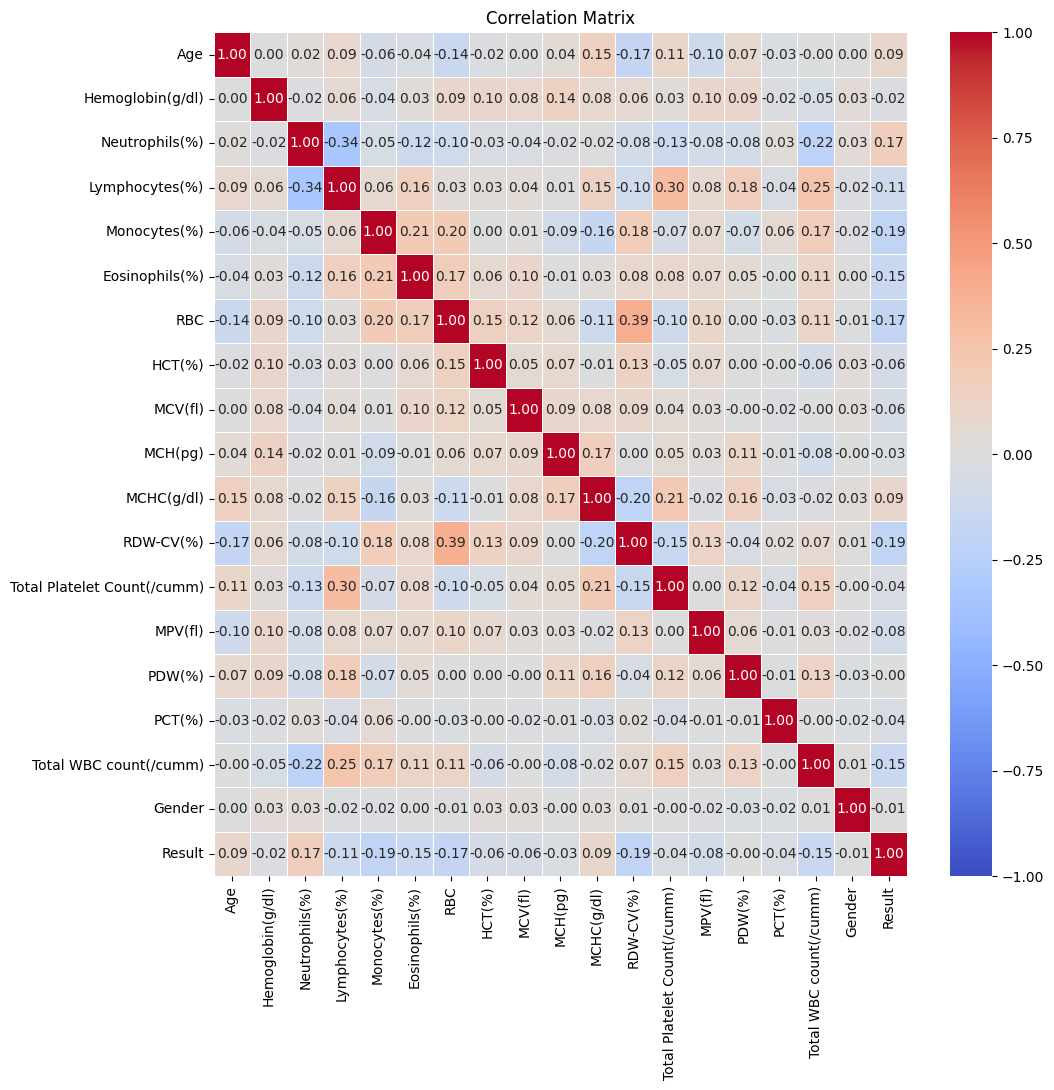

,corr_with_Result
RDW-CV(%),-0.192738
Monocytes(%),-0.192618
RBC,-0.173475
Neutrophils(%),0.170439
Total WBC count(/cumm),-0.147754
Eosinophils(%),-0.146679
Lymphocytes(%),-0.112497
Age,0.090345
MCHC(g/dl),0.087836
MPV(fl),-0.084790


In [12]:
feature_candidates = pollutant_cols + ["Gender", "Result"]
corr_matrix = df[feature_candidates].corr(numeric_only = True)
plt.figure(figsize=(11,11))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin = -1,
    vmax = 1,
    fmt=".2f",
    linewidths= 0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
corr_with_target = corr_matrix["Result"].drop("Result")
corr_with_target =  corr_with_target.sort_values(key = lambda s: s.abs(),ascending=False)
display(corr_with_target.to_frame("corr_with_Result"))

In [13]:
selected_features = [
        "Age",
        "Hemoglobin(g/dl)",
        "Neutrophils(%)",
        "Lymphocytes(%)",
        "Monocytes(%)",
        "Eosinophils(%)",
        "RBC",
        "HCT(%)",
        "MCV(fl)",
        "MCH(pg)",
        "MCHC(g/dl)",
        "RDW-CV(%)",
        "Total Platelet Count(/cumm)",
        "MPV(fl)",
        "PCT(%)",
        "Total WBC count(/cumm)"
]
x = daily_clean[selected_features]
y = daily_clean["Result"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="mean")
x_train_imp = imputer.fit_transform(x_train)
x_test_imp = imputer.transform(x_test)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Train:", x_train.shape)
print("Test:", x_test.shape)


Train: (1218, 16)
Test: (305, 16)


In [14]:


model_LR = LogisticRegression(random_state=42)

model_LR.fit(x_train_scaled, y_train)

y_pred_LR = model_LR.predict(x_test_scaled)

accuracy_LR = accuracy_score(y_test, y_pred_LR)
precision_LR = precision_score(y_test, y_pred_LR)
recall_LR = recall_score(y_test, y_pred_LR)
f1_LR = f1_score(y_test, y_pred_LR)

result_df_LR = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_LR],
    "Precision": [precision_LR],
    "Recall": [recall_LR],
    "F1-Score": [f1_LR]
})

display(result_df_LR)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.747541,0.757576,0.938967,0.838574


In [15]:
train_recall = recall_score(y_train, model_LR.predict(x_train_scaled))
train_precision = precision_score(y_train, model_LR.predict(x_train_scaled))
train_f1 = f1_score(y_train, model_LR.predict(x_train_scaled))
train_accuracy = accuracy_score(y_train, model_LR.predict(x_train_scaled))

test_recall = recall_score(y_test, y_pred_LR)
test_precision = precision_score(y_test, y_pred_LR)
test_f1 = f1_score(y_test, y_pred_LR)
test_accuracy = accuracy_score(y_test, y_pred_LR)

print("Train Recall:", train_recall, "Test Recall", test_recall)
print("Train Precision:", train_precision, "Test Pre", test_precision)
print("Train F1-Score:", train_f1, "F1", test_f1)
print("Train Accuracy:", train_accuracy, "Test acc", test_accuracy)

Train Recall: 0.9613992762364294 Test Recall 0.9389671361502347
Train Precision: 0.7420856610800745 Test Pre 0.7575757575757576
Train F1-Score: 0.837624802942722 F1 0.8385744234800838
Train Accuracy: 0.7463054187192119 Test acc 0.7475409836065574


In [16]:

model_tree = DecisionTreeClassifier(random_state=42)

model_tree.fit(x_train_imp, y_train)

y_pred_tree = model_tree.predict(x_test_imp)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

result_tree_df = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy_tree],
    "Precision": [precision_tree],
    "Recall": [recall_tree],
    "F1-score": [f1_tree]
})

display(result_tree_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.665574,0.763033,0.755869,0.759434


In [17]:
depth_values_forest = [3, 5, 8]
n_estimators_forest = [50, 100, 200, 300]
depth_results_forest = []
depth_predictions_forest = {}

for depth in depth_values_forest:
  for n in n_estimators_forest:
    model_forest = RandomForestClassifier(n_estimators = n ,max_depth=depth, random_state=42)
    model_forest.fit(x_train, y_train)
    y_pred = model_forest.predict(x_test)

    depth_predictions_forest[f"depth={depth}_trees={n}"] = y_pred
    recall_forest = recall_score(y_test, y_pred)
    precision_forest = precision_score(y_test, y_pred)
    f1_forest = f1_score(y_test, y_pred)
    accuracy_forest = accuracy_score(y_test, y_pred)
    depth_results_forest.append({
      "model": "Random Forest",
      "n_estimators": n,
      "max_depth": depth,
      "recall": recall_forest,
      "precision": precision_forest,
      "f1": f1_forest,
      "accuracy": accuracy_forest
  })
depth_results_df_forest = pd.DataFrame(depth_results_forest).sort_values("recall")
best_row = depth_results_df_forest.loc[
    depth_results_df_forest["recall"].idxmax()
]
best_depth = int(best_row["max_depth"])
best_trees = int(best_row["n_estimators"])
depth_predictions_forest[f"depth={depth}_trees={n}"] = y_pred
best_key = f"depth={best_depth}_trees={best_trees}"
display(depth_results_df_forest)


,model,n_estimators,max_depth,recall,precision,f1,accuracy
9,Random Forest,100,8,0.934272,0.768340,0.843220,0.757377
8,Random Forest,50,8,0.938967,0.772201,0.847458,0.763934
11,Random Forest,300,8,0.943662,0.770115,0.848101,0.763934
10,Random Forest,200,8,0.943662,0.767176,0.846316,0.760656
7,Random Forest,300,5,0.953052,0.774809,0.854737,0.773770
2,Random Forest,200,3,0.957746,0.764045,0.850000,0.763934
6,Random Forest,200,5,0.957746,0.778626,0.858947,0.780328
0,Random Forest,50,3,0.962441,0.767790,0.854167,0.770492
4,Random Forest,50,5,0.962441,0.773585,0.857741,0.777049
5,Random Forest,100,5,0.962441,0.779468,0.861345,0.783607


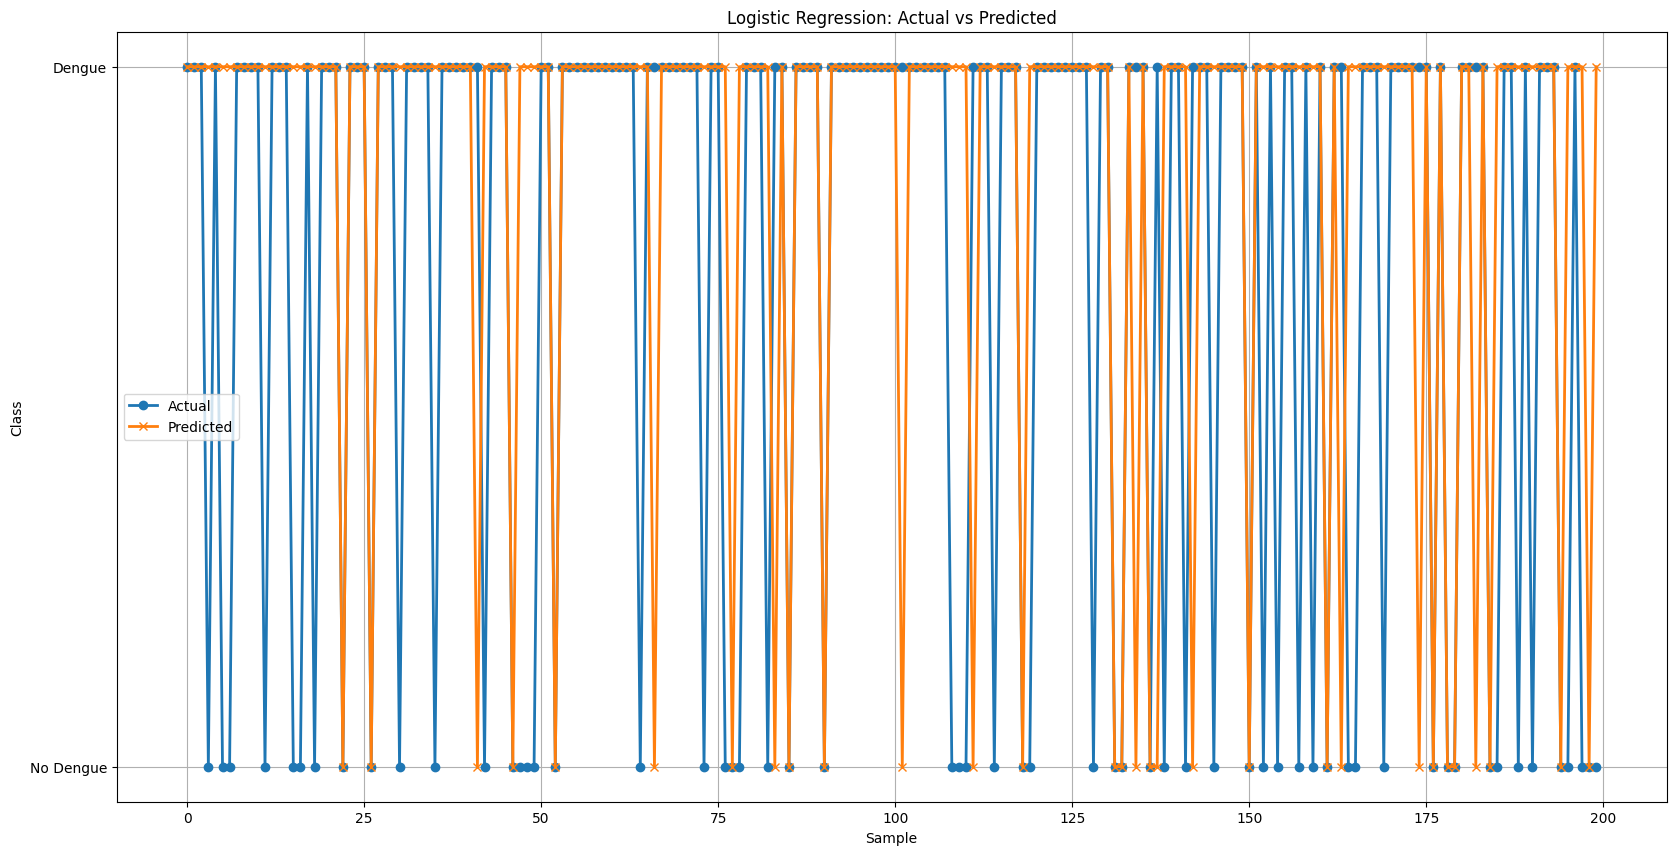

In [18]:


n = 200

plt.figure(figsize=(20,10))

plt.plot(
    y_test.iloc[:n].values,
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    y_pred_LR[:n],
    marker='x',
    linewidth=2,
    label='Predicted'
)

plt.title("Logistic Regression: Actual vs Predicted")
plt.xlabel("Sample")
plt.ylabel("Class")
plt.yticks([0,1], ["No Dengue", "Dengue"])
plt.legend()
plt.grid(True)

plt.show()

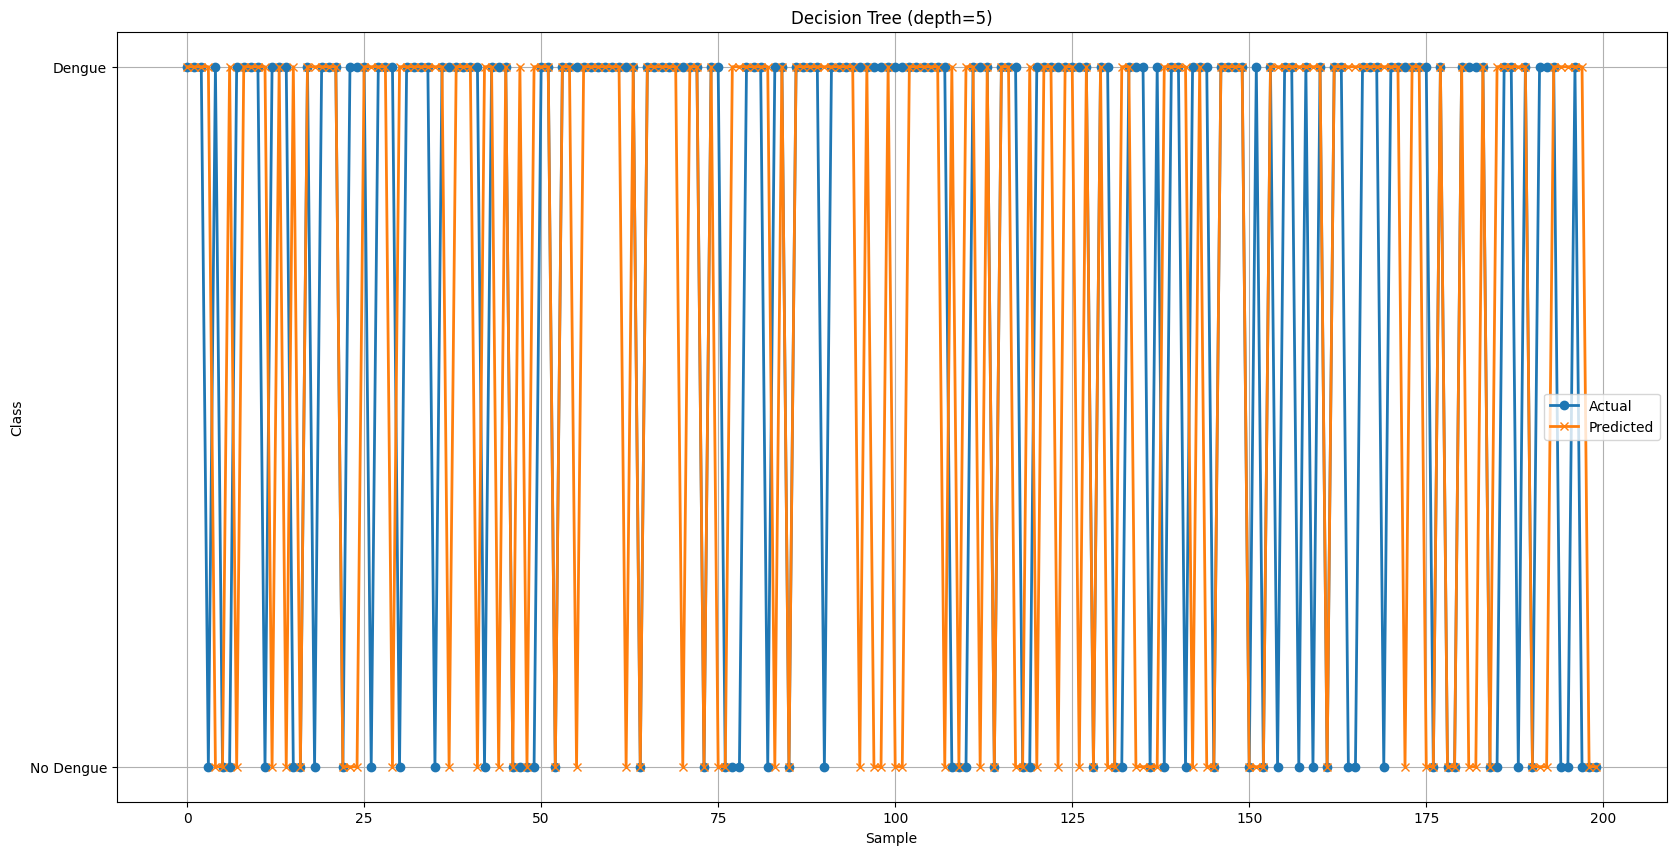

In [19]:
n_sample = 200

plt.figure(figsize=(20,10))

plt.plot(
    y_test.iloc[:n_sample].values,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_pred_tree[:n_sample],
    marker='x',
    linewidth=2,
    label="Predicted"
)
plt.yticks([0,1],["No Dengue", "Dengue"])
plt.xlabel("Sample")
plt.ylabel("Class")
plt.title("Decision Tree (depth=5)")
plt.legend()
plt.grid(True)
plt.show()

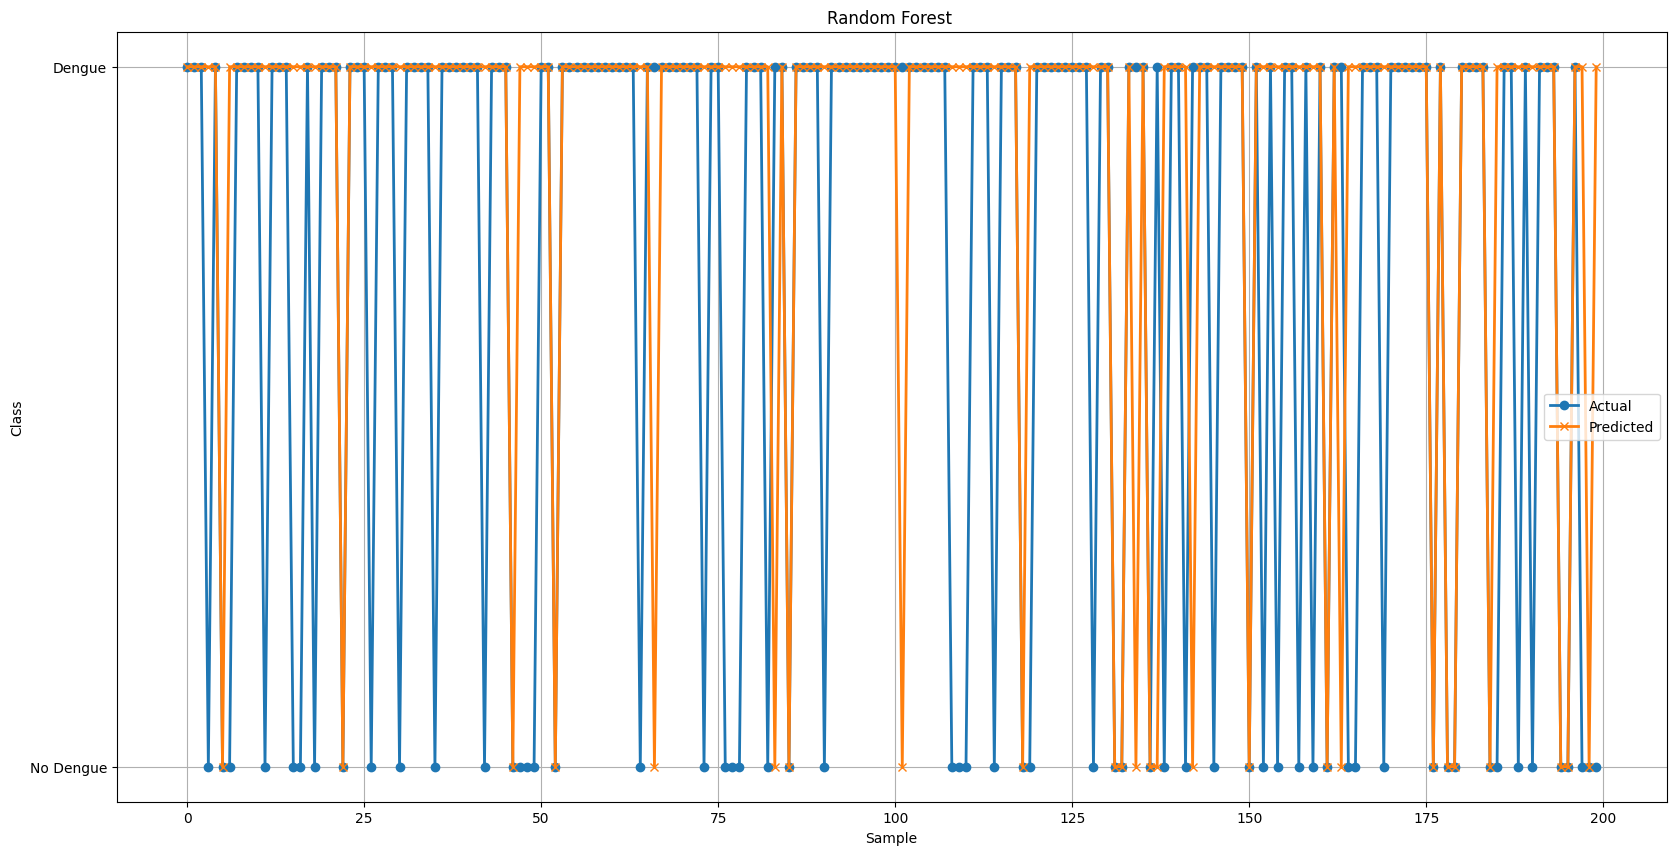

In [20]:
n_sample = 200

plt.figure(figsize=(20,10))

plt.plot(
    y_test.iloc[:n_sample].values,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    depth_predictions_forest[best_key][:n_sample],
    marker='x',
    linewidth=2,
    label="Predicted"
)

plt.yticks([0,1],["No Dengue","Dengue"])
plt.xlabel("Sample")
plt.ylabel("Class")
plt.title(f"Random Forest ")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
compare_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_LR,
        accuracy_tree,
        best_row["accuracy"]
    ],
    "Precision": [
        precision_LR,
        precision_tree,
        best_row["precision"]
    ],
    "Recall": [
        recall_LR,
        recall_tree,
        best_row["recall"]
    ],
    "F1-score": [
        f1_LR,
        f1_tree,
        best_row["f1"]
    ]
})

display(compare_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.747541,0.757576,0.938967,0.838574
1,Decision Tree,0.665574,0.763033,0.755869,0.759434
2,Random Forest,0.770492,0.767790,0.962441,0.854167


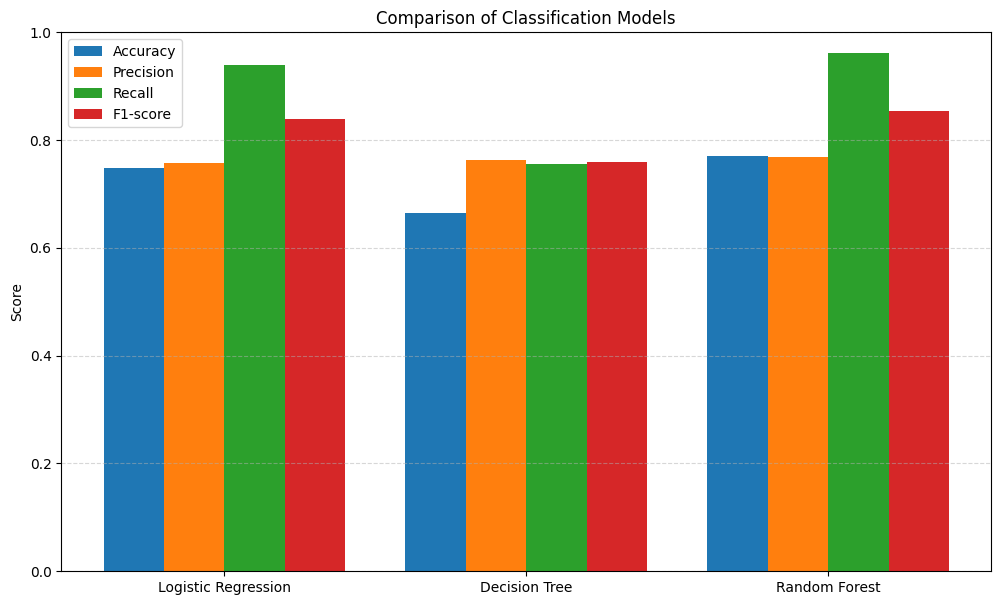

In [22]:


metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = np.arange(len(compare_df["Model"]))

width = 0.2

plt.figure(figsize=(12,7))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        compare_df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width*1.5,
    compare_df["Model"]
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Comparison of Classification Models")

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()